# Análisis Exploratorio de Datos (EDA) — Dataset del Titanic

**Objetivo:** explorar el dataset de pasajeros del Titanic para entender qué variables
se relacionan con la supervivencia, detectar valores faltantes, outliers y patrones
generales en los datos.

Dataset: https://www.kaggle.com/competitions/titanic (train.csv)


## 1. Importación de librerías

In [1]:
# LIBRERIAS PARA MANEJO DE DATOS Y VISUALIZACION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIGURACION DE ESTILO PARA LOS GRAFICOS
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


## 2. Carga del dataset

Se utiliza el archivo `titanic.csv` (equivalente al `train.csv` de la competencia de Kaggle),
que contiene 891 pasajeros con la variable objetivo `Survived`.


In [2]:
# CARGA DEL DATASET
df = pd.read_csv("titanic.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# DIMENSIONES DEL DATASET (FILAS, COLUMNAS)
df.shape


(891, 12)

In [4]:
# TIPOS DE DATOS Y CANTIDAD DE VALORES NO NULOS POR COLUMNA
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Diccionario de variables

| Columna | Descripción |
|---|---|
| PassengerId | Identificador único del pasajero |
| Survived | 0 = No sobrevivió, 1 = Sobrevivió |
| Pclass | Clase del pasaje (1 = Primera, 2 = Segunda, 3 = Tercera) |
| Name | Nombre del pasajero |
| Sex | Sexo |
| Age | Edad en años |
| SibSp | Cantidad de hermanos/cónyuges a bordo |
| Parch | Cantidad de padres/hijos a bordo |
| Ticket | Número de ticket |
| Fare | Tarifa pagada |
| Cabin | Número de cabina |
| Embarked | Puerto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton) |


## 3. Valores faltantes

In [5]:
# CANTIDAD Y PORCENTAJE DE VALORES FALTANTES POR COLUMNA
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df) * 100).round(2)

resumen_faltantes = pd.DataFrame({
    "faltantes": faltantes,
    "porcentaje_%": porcentaje
}).sort_values("faltantes", ascending=False)

resumen_faltantes[resumen_faltantes["faltantes"] > 0]


,faltantes,porcentaje_%
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


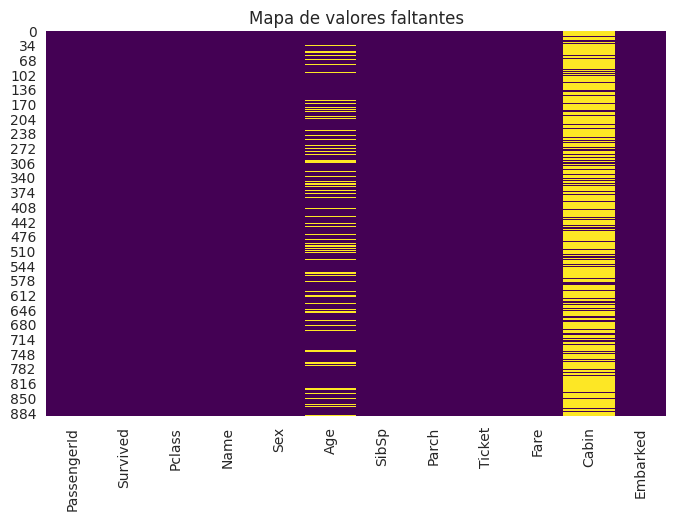

In [6]:
# VISUALIZACION DE VALORES FALTANTES
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de valores faltantes")
plt.show()


**Observación:** `Cabin` tiene muchísimos valores faltantes (más del 75%), por lo que
en general se descarta o se transforma en una variable binaria (tiene/no tiene cabina
registrada). `Age` tiene un porcentaje moderado de faltantes que suele imputarse.
`Embarked` tiene solo 2 valores faltantes.


## 4. Estadísticas descriptivas

In [7]:
# ESTADISTICAS DESCRIPTIVAS DE VARIABLES NUMERICAS
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# ESTADISTICAS DESCRIPTIVAS DE VARIABLES CATEGORICAS
df.describe(include="object")


/tmp/ipykernel_536/3294040189.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [9]:
# TASA GENERAL DE SUPERVIVENCIA
tasa_supervivencia = df["Survived"].mean() * 100
print(f"Tasa de supervivencia general: {tasa_supervivencia:.2f}%")


Tasa de supervivencia general: 38.38%


## 5. Análisis univariado

/tmp/ipykernel_536/393724507.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Survived", data=df, palette="Set2")


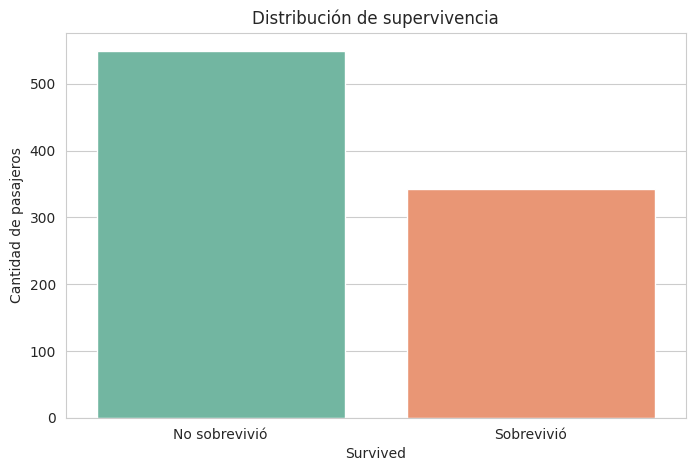

In [10]:
# DISTRIBUCION DE SUPERVIVENCIA
plt.figure()
sns.countplot(x="Survived", data=df, palette="Set2")
plt.xticks([0, 1], ["No sobrevivió", "Sobrevivió"])
plt.title("Distribución de supervivencia")
plt.ylabel("Cantidad de pasajeros")
plt.show()


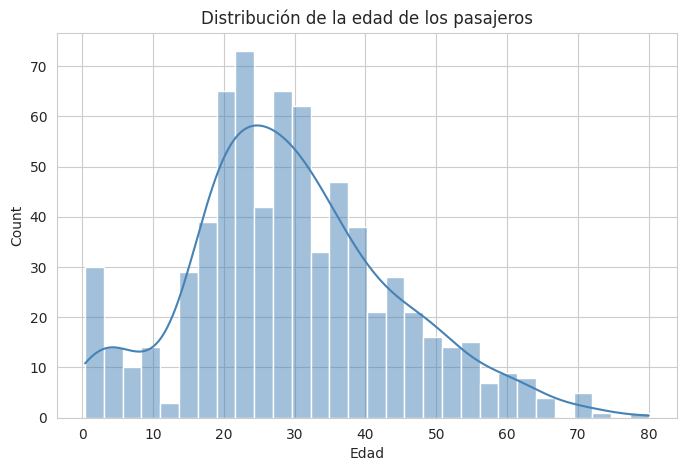

In [11]:
# DISTRIBUCION DE EDAD
plt.figure()
sns.histplot(df["Age"].dropna(), bins=30, kde=True, color="steelblue")
plt.title("Distribución de la edad de los pasajeros")
plt.xlabel("Edad")
plt.show()


/tmp/ipykernel_536/3741185988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Pclass", data=df, palette="pastel", ax=axes[0])
/tmp/ipykernel_536/3741185988.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sex", data=df, palette="pastel", ax=axes[1])


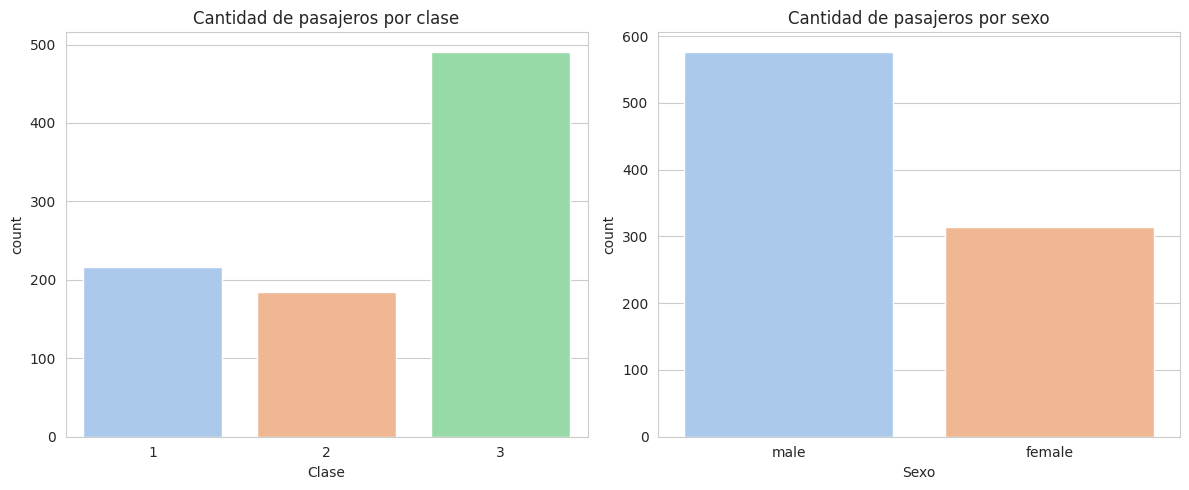

In [12]:
# DISTRIBUCION POR CLASE Y SEXO
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="Pclass", data=df, palette="pastel", ax=axes[0])
axes[0].set_title("Cantidad de pasajeros por clase")
axes[0].set_xlabel("Clase")

sns.countplot(x="Sex", data=df, palette="pastel", ax=axes[1])
axes[1].set_title("Cantidad de pasajeros por sexo")
axes[1].set_xlabel("Sexo")

plt.tight_layout()
plt.show()


## 6. Supervivencia según otras variables

/tmp/ipykernel_536/4220657258.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df, palette="Set2")


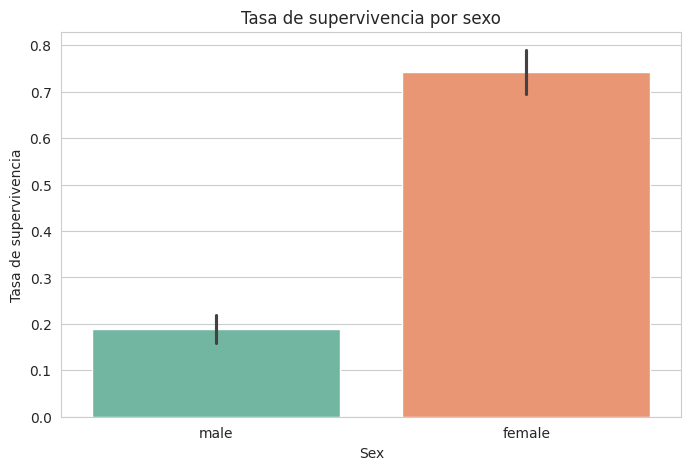

Sex
female    74.2
male      18.9
Name: Survived, dtype: float64

In [13]:
# SUPERVIVENCIA SEGUN SEXO
plt.figure()
sns.barplot(x="Sex", y="Survived", data=df, palette="Set2")
plt.title("Tasa de supervivencia por sexo")
plt.ylabel("Tasa de supervivencia")
plt.show()

df.groupby("Sex")["Survived"].mean().round(3) * 100


/tmp/ipykernel_536/949337152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df, palette="Set2")


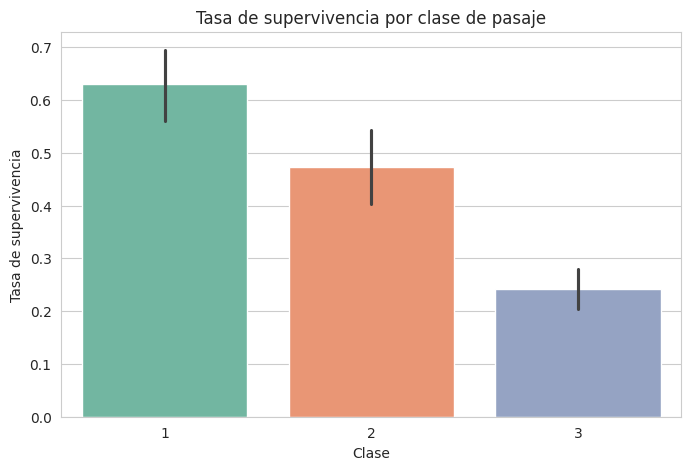

Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64

In [14]:
# SUPERVIVENCIA SEGUN CLASE
plt.figure()
sns.barplot(x="Pclass", y="Survived", data=df, palette="Set2")
plt.title("Tasa de supervivencia por clase de pasaje")
plt.xlabel("Clase")
plt.ylabel("Tasa de supervivencia")
plt.show()

df.groupby("Pclass")["Survived"].mean().round(3) * 100


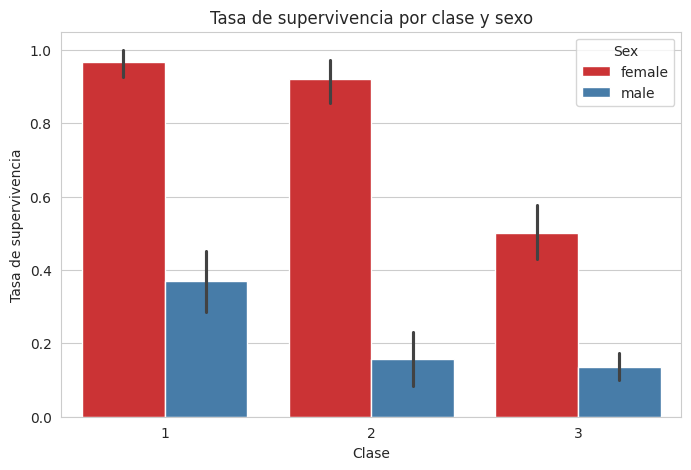

In [15]:
# SUPERVIVENCIA SEGUN SEXO Y CLASE COMBINADOS
plt.figure()
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df, palette="Set1")
plt.title("Tasa de supervivencia por clase y sexo")
plt.xlabel("Clase")
plt.ylabel("Tasa de supervivencia")
plt.show()


/tmp/ipykernel_536/3893502007.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Embarked", y="Survived", data=df, palette="Set2")


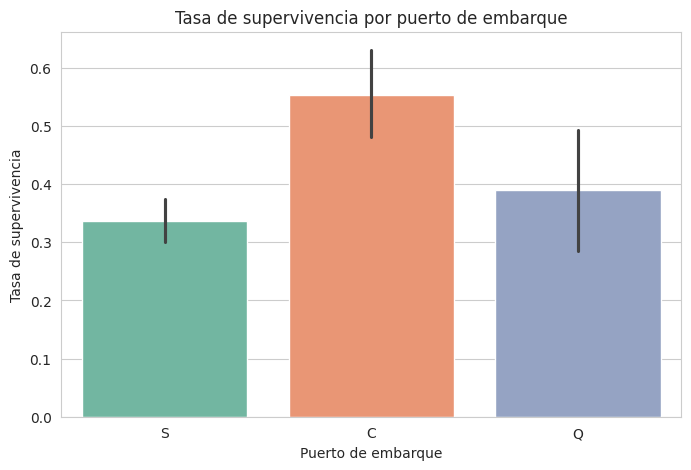

In [16]:
# SUPERVIVENCIA SEGUN PUERTO DE EMBARQUE
plt.figure()
sns.barplot(x="Embarked", y="Survived", data=df, palette="Set2")
plt.title("Tasa de supervivencia por puerto de embarque")
plt.xlabel("Puerto de embarque")
plt.ylabel("Tasa de supervivencia")
plt.show()


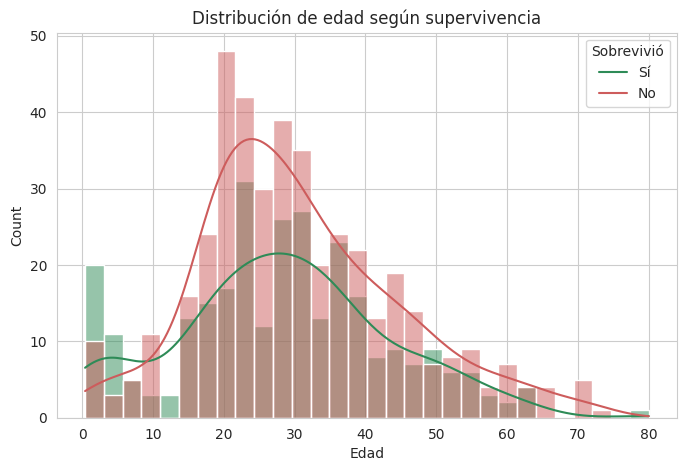

In [17]:
# DISTRIBUCION DE EDAD SEGUN SUPERVIVENCIA
plt.figure()
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True,
             palette={0: "indianred", 1: "seagreen"}, multiple="layer", alpha=0.5)
plt.title("Distribución de edad según supervivencia")
plt.xlabel("Edad")
plt.legend(title="Sobrevivió", labels=["Sí", "No"])
plt.show()


/tmp/ipykernel_536/1651981928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Survived", y="Fare", data=df, palette="Set2")


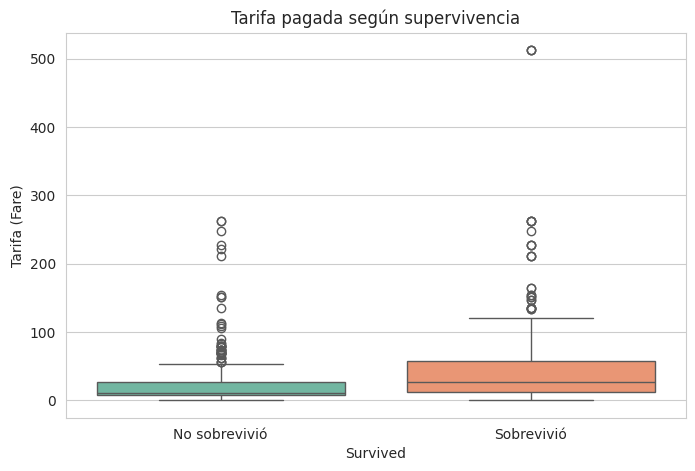

In [18]:
# TARIFA PAGADA SEGUN SUPERVIVENCIA
plt.figure()
sns.boxplot(x="Survived", y="Fare", data=df, palette="Set2")
plt.title("Tarifa pagada según supervivencia")
plt.xticks([0, 1], ["No sobrevivió", "Sobrevivió"])
plt.ylabel("Tarifa (Fare)")
plt.show()


/tmp/ipykernel_536/2776047970.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="FamiliaTotal", y="Survived", data=df, palette="Set2")


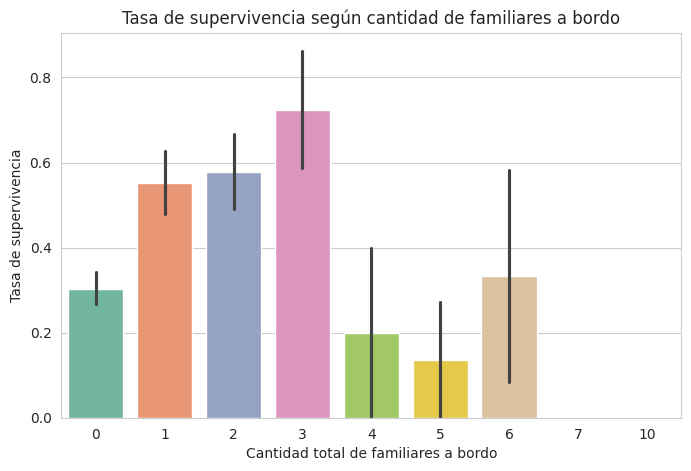

In [19]:
# CANTIDAD DE FAMILIARES A BORDO (SibSp + Parch) VS SUPERVIVENCIA
df["FamiliaTotal"] = df["SibSp"] + df["Parch"]

plt.figure()
sns.barplot(x="FamiliaTotal", y="Survived", data=df, palette="Set2")
plt.title("Tasa de supervivencia según cantidad de familiares a bordo")
plt.xlabel("Cantidad total de familiares a bordo")
plt.ylabel("Tasa de supervivencia")
plt.show()


## 7. Correlación entre variables numéricas

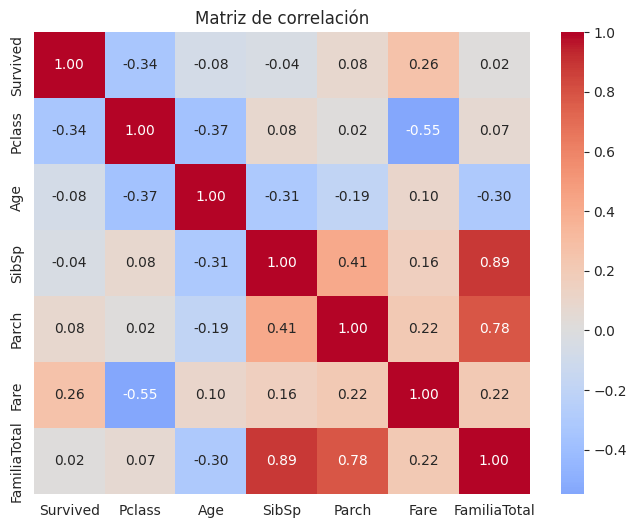

In [20]:
# MATRIZ DE CORRELACION
variables_numericas = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamiliaTotal"]]
correlacion = variables_numericas.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Matriz de correlación")
plt.show()


## 8. Conclusiones

A partir del análisis exploratorio se observa que:

- **Sexo:** las mujeres tuvieron una tasa de supervivencia notablemente mayor que los
  hombres ("mujeres y niños primero").
- **Clase del pasaje:** a mayor clase (1ra > 2da > 3ra), mayor probabilidad de
  supervivencia; esto se relaciona con la cercanía a los botes salvavidas y el estatus
  socioeconómico.
- **Edad:** los niños tuvieron mayor tasa de supervivencia que los adultos.
- **Tarifa (Fare):** quienes pagaron tarifas más altas (asociadas a mejores clases)
  tendieron a sobrevivir más.
- **Familiares a bordo:** viajar con una cantidad moderada de familiares (1 a 3) parece
  asociarse a mayor supervivencia que viajar solo o con una familia muy numerosa.
- **Valores faltantes:** `Cabin` tiene demasiados datos faltantes para usarse
  directamente; `Age` requiere imputación; `Embarked` tiene solo 2 valores faltantes.

Estos hallazgos son consistentes con el contexto histórico del hundimiento del Titanic
y sientan las bases para un eventual modelo predictivo de supervivencia.
